# Python Lesson 34: Second Derivative and Curvature

**Concept page:** `wiki/concepts/second-derivative-and-curvature.md` · **Area:** calculus

**You will be able to:**
- compute f'' and classify critical points
- find inflection points
- read a sign table from code

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. y = ln(x)/x (Grade 12 basic example)

In [2]:
x=sp.symbols('x',positive=True); y=sp.log(x)/x
y1=sp.simplify(sp.diff(y,x)); y2=sp.simplify(sp.diff(y,x,2)); print(y1); print(y2)
print("critical:",sp.solve(y1,x),"  inflection:",sp.solve(y2,x))

(1 - log(x))/x**2
(2*log(x) - 3)/x**3
critical: [E]   inflection: [exp(3/2)]


## 2. Sign table

In [3]:
yf=sp.lambdify(x,y,'numpy'); d1=sp.lambdify(x,y1,'numpy'); d2=sp.lambdify(x,y2,'numpy')
for pt in (1,2,np.e,4,np.exp(1.5)-0.2,np.exp(1.5)+0.2): print(f"x={pt:.3f} y'={d1(pt):+.4f} y''={d2(pt):+.4f}")

x=1.000 y'=+1.0000 y''=-3.0000
x=2.000 y'=+0.0767 y''=-0.2017
x=2.718 y'=+0.0000 y''=-0.0498
x=4.000 y'=-0.0241 y''=-0.0036
x=4.282 y'=-0.0248 y''=-0.0012
x=4.682 y'=-0.0248 y''=+0.0009


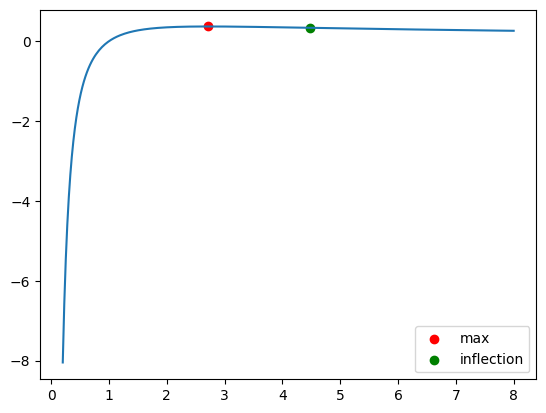

In [4]:
xs=np.linspace(0.2,8,300); plt.plot(xs,yf(xs)); plt.scatter([np.e],[1/np.e],c='r',label='max'); plt.scatter([np.exp(1.5)],[yf(np.exp(1.5))],c='g',label='inflection'); plt.legend(); plt.show()

## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 12 basic p. 99–101: y=ln x / x has maximum 1/e at x=e and an inflection at x=e^{3/2}.

In [5]:
print(np.exp(1.5), 3/(2*np.exp(1.5)))

4.4816890703380645 0.33469524022264474


## Exercises

**Exercise 1.** Classify the critical point of f(x)=x^3-3x via f''.

In [6]:
# your code here

**Exercise 2.** Find the inflection point of f(x)=x^3-6x^2+9x.

In [7]:
# your code here

## Solutions
*(Try the exercises first!)*

In [8]:
# Solution 1
x=sp.symbols('x'); f=x**3-3*x; crit=sp.solve(sp.diff(f,x),x); print([(c,sp.diff(f,x,2).subs(x,c)) for c in crit])

[(-1, -6), (1, 6)]


In [9]:
# Solution 2
x=sp.symbols('x'); assert sp.solve(sp.diff(x**3-6*x**2+9*x,x,2),x)==[2]